Практическая работа №1  
Статистическое определение вероятности  
Миронов Артём Евгеньевич   
Группа: 514-1

In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt

data = pd.read_csv("variant58.csv")
data.head()

,Unnamed: 0,SEX
0,0,M
1,1,M
2,2,F
3,3,M
4,4,M


In [2]:
n_total = len(data)

max_power = int(math.log10(n_total))

sample_volumes = [
    math.ceil(n_total / (10 ** i))
    for i in range(1, max_power)
]

sample_volumes

[10000, 1000, 100, 10]

In [3]:
results_list = []

for volume in sample_volumes:
    for i in range(100):
        sample = data.sample(n=volume)

        counts = sample["SEX"].value_counts()
        boys_count = counts.get("M", 0)
        frequency = boys_count / volume

        temp_df = pd.DataFrame({
            "Объём выборки": [volume],
            "Относительная частота мальчика": [frequency]
        })

        results_list.append(temp_df)

result = pd.concat(results_list, ignore_index=True)
result.head()

,Объём выборки,Относительная частота мальчика
0,10000,0.5176
1,10000,0.5105
2,10000,0.5090
3,10000,0.5174
4,10000,0.5212


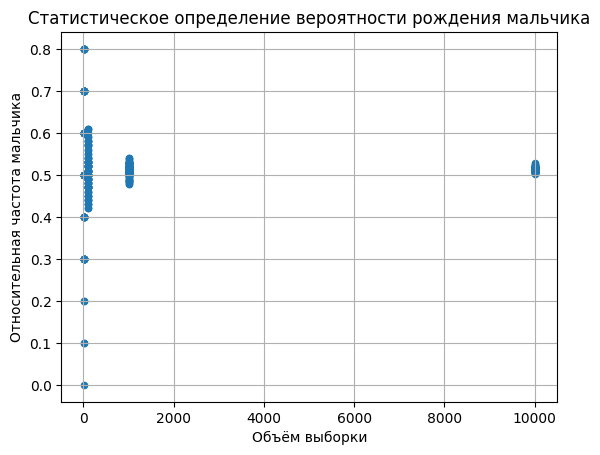

In [4]:
ax = result.plot(
    x="Объём выборки",
    y="Относительная частота мальчика",
    kind="scatter",
    title="Статистическое определение вероятности рождения мальчика",
    grid=True
)

ax.set_xlabel("Объём выборки")
ax.set_ylabel("Относительная частота мальчика")
plt.show()

In [5]:
result.to_csv(
    "relative_frequencies.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

In [6]:
plt.figure()
result.plot(
    x="Объём выборки",
    y="Относительная частота мальчика",
    kind="scatter",
    title="Статистическое определение вероятности рождения мальчика",
    grid=True
)
plt.xlabel("Объём выборки")
plt.ylabel("Относительная частота мальчика")
plt.savefig("scatter_plot.png", dpi=200, bbox_inches="tight")
plt.close()

<Figure size 640x480 with 0 Axes>

Вопрос 1: Наблюдается ли на примере составленных выборок устойчивость относительных частот?
Ответ:
Да, наблюдается явление устойчивости относительных частот, которое и лежит в основе статистического определения вероятности.
При маленьких объемах выборки (например, 1, 10, 100) точки на графике сильно разбросаны. 

При увеличении объема выборки (1000, 10000) точки начинают группироваться вокруг значения 0.512. Чем больше объем, тем меньше дисперсия значений относительной частоты.

Это говорит о том, что хоть исход каждого отдельного рождения случайный,  при увеличении размера выборки частота события стремится к некоторой постоянной величине.

Вопрос 2: Как влияет на результаты увеличение объёма выборки?
Ответ:
Сходимость к вероятности (Закон больших чисел): Относительная частота события приближается к его теоретической/истинной вероятности. На графике это видно по тому, что "облако" точек сужается и центрируется около значения 0.512.

Повышение точности оценки: Большая выборка дает нам гораздо более надежную оценку вероятности. Разброс уменьшается значения становятся стабильнее и кучнее.